# DESeq2 DE Analysis Pipeline
- 依赖包:
   - DESeq2
   - RColorBrewer
   - gplots
   - pheatmap
   - ggplot2
- DESeq2对于输入数据的要求
   - 输入数据为整数构成的矩阵
   - 此矩阵必须是没有经过标准化(归一化/Normalize) 
- DESeq2进行差异表达分析
   - 构建dds矩阵
       ```
       dds <- DESeqDataSetFromMatrix(
                   countData = cts, 
                   colData = coldata, 
                   design= ~ batch + condition) 
       #~在R里面用于构建公式对象，~左边为因变量，右边为自变量。
       ```

   - 标准化/归一化
       ```
       dds <- DESeq(dds) 
       #标准化
       ```
   - 差异分析
       ```
       res <- results(dds, contrast=c("condition","treated","control")) 
       #差异分析结果
       ```

In [70]:
### read data ------------------------------------------------------------------------------>
colData <- read.csv(file = "sample.tsv", sep = "\t")
rawcts <- read.csv(file = "exp_v2.csv", row.names=1,)

In [71]:
head(rawcts,4)

,GSM425929,GSM425930,GSM425931,GSM425932,GSM425933,GSM425934,GSM425935,GSM425936,GSM425937,GSM425938,⋯,GSM425919,GSM425920,GSM425921,GSM425922,GSM425923,GSM425924,GSM425925,GSM425926,GSM425927,GSM425928
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
A1BG,3,4,5,5,5,4,4,3,2,3,⋯,4,4,5,5,4,5,3,5,4,3
A1BG-AS1,5,5,3,3,3,5,3,4,3,5,⋯,3,3,3,5,5,4,5,3,3,4
A1CF,5,4,4,4,4,4,5,5,4,5,⋯,4,5,5,5,5,5,5,5,4,5
A2M,7,8,8,6,7,7,7,7,7,7,⋯,7,8,7,6,7,8,7,7,7,7


1. 读取样本信息（sample.txt）
2. 读取featureCounts产生的各个bam文件的counts信息
3. 检查rawcts中的所有记录(row)的个数，这里代表count到的gene的个数, geneid被指定为row.names了所以不计在内

In [72]:
# 21653 transcripts, 104 exps
dim(rawcts)

[1] 21653   103

In [73]:
# 看一下colData
# 样本名称、处理条件
head(colData)

,sample,condition
,<chr>,<chr>
1,GSM425929,ctrl
2,GSM425930,ctrl
3,GSM425931,ctrl
4,GSM425932,ctrl
5,GSM425933,ctrl
6,GSM425934,ctrl


In [74]:
head(colData)

,sample,condition
,<chr>,<chr>
1,GSM425929,ctrl
2,GSM425930,ctrl
3,GSM425931,ctrl
4,GSM425932,ctrl
5,GSM425933,ctrl
6,GSM425934,ctrl


In [75]:
# 看一下rawcts
# 这个很简单就是geneid为index，样本信息的counts数为columns
head(rawcts)

,GSM425929,GSM425930,GSM425931,GSM425932,GSM425933,GSM425934,GSM425935,GSM425936,GSM425937,GSM425938,⋯,GSM425919,GSM425920,GSM425921,GSM425922,GSM425923,GSM425924,GSM425925,GSM425926,GSM425927,GSM425928
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
A1BG,3,4,5,5,5,4,4,3,2,3,⋯,4,4,5,5,4,5,3,5,4,3
A1BG-AS1,5,5,3,3,3,5,3,4,3,5,⋯,3,3,3,5,5,4,5,3,3,4
A1CF,5,4,4,4,4,4,5,5,4,5,⋯,4,5,5,5,5,5,5,5,4,5
A2M,7,8,8,6,7,7,7,7,7,7,⋯,7,8,7,6,7,8,7,7,7,7
A2M-AS1,6,6,7,6,6,6,6,6,6,6,⋯,6,5,6,6,5,6,5,4,5,7
A2ML1,4,3,3,3,4,4,4,4,4,5,⋯,4,3,5,3,4,4,4,4,4,5


4. 过滤掉行的和为0，也就是没有bam文件中count到reads的genes

In [76]:
### filt genes that don't express in all sample -------------------------------------------->
rawcts <- rawcts[rowSums(rawcts)>0,]
dim(rawcts)

[1] 21653   103

5. rownames函数调用矩阵的row.names
6. 调用stringr package中的str_split函数，去除geneid中的gene名的.以及后面的内容
7. 使用duplicated函数去掉重复的gn id   
   - 去重63个

In [77]:
### remove version in ensembl id ----------------------------------------------------------->
gn <- stringr::str_split(rownames(rawcts),"\\.",simplify = T)[,1]
# remove duplicate
rawcts <- rawcts[!duplicated(gn),]
rownames(rawcts) <- gn[!duplicated(gn)]
dim(rawcts)

[1] 21590   103

## 1. 构建dds矩阵

8. 将count的矩阵输入DESeq2的DESeqDataSetFromMatrix函数中，产生dds(DEseq Data Set)


构建dds矩阵需要：

- 表达矩阵
   - 即上述代码中的countData，就是我们前面通过read count计算后并融合生成的矩阵，行row为各个基因，列col为各个样品，中间为计算reads或者fragment得到的整数。我们后面要用的是这个文件（mouse_all_count.txt）
- 样品信息
   - 矩阵即上述代码中的colData，它的类型是一个dataframe（数据框），这个东西叫【元数据】
   - 第一列是样品名称，
   - 第二列是样品的处理情况（对照还是处理等），即condition，condition的类型是一个factor
   - 第三列type可以理解为宏观的处理条件，需要时使用，用不着也可以留空
   
   - 这里我用第三列的type作为自变量(你也可以用第二列的condition)
- 差异比较矩阵
   - 即上述代码中的design。
   - 差异比较矩阵就是告诉差异分析函数是要分析哪些变量间的差异
   - 简单说就是说明哪些是对照哪些是处理。

In [78]:
### DEseq analyses ------------------------------------------------------------------------->
library(DESeq2)
dds <- DESeqDataSetFromMatrix(countData = rawcts,
                              colData = colData,
                              design = ~ condition) 
                            # ~在R里面用于构建公式对象，~左边为因变量(design)，右边为自变量(type) 
dds

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:parallel’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply

class: DESeqDataSet 
dim: 21590 103 
metadata(1): version
assays(1): counts
rownames(21590): A1BG A1BG-AS1 ... ZZEF1 ZZZ3
rowData names(0):
colnames(103): GSM425929 GSM425930 ... GSM425927 GSM425928
colData names(2): sample condition

In [79]:
# 预过滤
# 虽然不必在运行DESeq2函数之前对低计数基因进行预过滤，但是有两个原因使预过滤有用：
# - 通过删除读取次数很少的行，我们减小了dds数据对象的内存大小，并且我们提高了DESeq2中转换和测试功能的速度。
# - 在这里，我们执行最小的预过滤，以仅保留总读取次数至少为10的行。
# - 请注意，对结果函数中的归一化计数的平均值进行独立滤波后，会自动应用更严格的滤波以增加功率。

# keep <- rowSums(counts(dds)) >= 10
# dds <- dds[keep,]
# dds

9. 将dds输入DESeq函数#原始dds进行normalize
DESeq包含三步:
- estimation of size factors（estimateSizeFactors)
- estimation of dispersion（estimateDispersons)
- Negative Binomial GLM fitting and Wald statistics（nbinomWaldTest）
- 【可以分布运行，也可用一步到位，最后返回 results可用的DESeqDataSet对象。】

In [80]:
dds <- DESeq(dds)
dds

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



class: DESeqDataSet 
dim: 21590 103 
metadata(1): version
assays(5): counts mu H cooks originalCounts
rownames(21590): A1BG A1BG-AS1 ... ZZEF1 ZZZ3
rowData names(23): baseMean baseVar ... maxCooks replace
colnames(103): GSM425929 GSM425930 ... GSM425927 GSM425928
colData names(4): sample condition sizeFactor replaceable

10. Plot Dispersion Estimates
- 观察数据的离散情况
- A simple helper function that plots the per-gene dispersion estimates together with the fitted mean-dispersion relationship.

Arguments
- object
   - a DESeqDataSet, with dispersions estimated
- ymin
   - the lower bound for points on the plot, points beyond this are drawn as triangles at ymin
- genecol
   - the color for gene-wise dispersion estimates
- fitcol
   - the color of the fitted estimates
- finalcol
   - the color of the final estimates used for testing
- legend
   - logical, whether to draw a legend
- [文档](https://www.rdocumentation.org/packages/DESeq2/versions/1.12.3/topics/plotDispEsts)

In [130]:
pdf("000_Dispersion_plot.pdf",width=8,height=8)
plotDispEsts(dds, main="Dispersion plot")
dev.off()

pdf 
  2

11. 将结果用results()函数来获取，赋值给res变量

In [84]:
res <- results(dds,contrast=c("condition", "treat", "ctrl"))
# summary一下，看一下结果的概要信息
summary(res)


out of 21590 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 0, 0%
LFC < 0 (down)     : 8, 0.037%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



12. normalization前面的数据分布差异

In [113]:
### rld normalization ---------------------------------------------------------------------->
## 下面的代码如果你不感兴趣不需要运行，免得误导你
## 就是看看normalization前面的数据分布差异
rld <- rlogTransformation(dds)
rawcts_new=assay(rld)
par(cex = 0.7)
n.sample=ncol(rawcts)
if(n.sample>40) par(cex = 0.5)
cols <- rainbow(n.sample*1.2)
# 上一步比较耗时，算数据分布用

rlog() may take a long time with 50 or more samples,
vst() is a much faster transformation



In [126]:
pdf("001_expression_value_compare.pdf",width=20,height=15)
par(mfrow=c(1,2))
boxplot(rawcts, col = cols,main="expression value_rawcts: before nornalization",las=2)
boxplot(rawcts_new, col = cols,main="expression value_rawcts_new: after nornalization",las=2)
dev.off()

pdf 
  2

In [136]:
pdf("002_expression_distribution_info_hist.pdf",width=8,height=8)
hist(rawcts_new)
dev.off()

pdf 
  2

13. plot correlation heatmap

In [137]:
# 查看rawcts_new
head(rawcts_new)

,GSM425929,GSM425930,GSM425931,GSM425932,GSM425933,GSM425934,GSM425935,GSM425936,GSM425937,GSM425938,⋯,GSM425919,GSM425920,GSM425921,GSM425922,GSM425923,GSM425924,GSM425925,GSM425926,GSM425927,GSM425928
A1BG,1.805773,1.839397,1.871258,1.870804,1.870350,1.838247,1.837840,1.804999,1.773885,1.805168,⋯,1.839783,1.838681,1.866756,1.865262,1.837882,1.867809,1.806125,1.870597,1.842467,1.803918
A1BG-AS1,1.822503,1.823873,1.759103,1.758709,1.758313,1.822686,1.757867,1.789634,1.758792,1.821842,⋯,1.759654,1.758640,1.755183,1.817797,1.822310,1.788338,1.822888,1.758528,1.762121,1.788518
A1CF,2.122744,2.092617,2.092374,2.091884,2.091392,2.091303,2.122469,2.121761,2.091987,2.121976,⋯,2.093058,2.123478,2.118970,2.117274,2.122520,2.120166,2.123192,2.123332,2.096127,2.120388
A2M,2.824160,2.856206,2.855812,2.795488,2.824619,2.824479,2.823749,2.822693,2.825552,2.823013,⋯,2.827232,2.854880,2.818529,2.786402,2.823825,2.849778,2.824829,2.825038,2.832050,2.820644
A2M-AS1,2.432282,2.434197,2.464559,2.433272,2.432651,2.432539,2.431951,2.431100,2.433402,2.431358,⋯,2.434754,2.402243,2.427746,2.425709,2.401137,2.429183,2.401913,2.370882,2.407491,2.459941
A2ML1,1.990368,1.959652,1.959433,1.958993,1.990646,1.990561,1.990120,1.989480,1.991210,2.021436,⋯,1.992225,1.958916,2.018579,1.953601,1.990165,1.988040,1.990773,1.990899,1.995133,2.019927


In [141]:
### plot correlation heatmap -------------------------------------------------------------->
library(RColorBrewer)
(mycols <- brewer.pal(8, "Dark2")[1:length(unique(colData$condition))])
# Sample distance heatmap
sampleDists <- dist(t(rawcts_new))
sampleDistsMatrix <- as.matrix(sampleDists)
head(sampleDistsMatrix)

[1] "#1B9E77" "#D95F02"

,GSM425929,GSM425930,GSM425931,GSM425932,GSM425933,GSM425934,GSM425935,GSM425936,GSM425937,GSM425938,⋯,GSM425919,GSM425920,GSM425921,GSM425922,GSM425923,GSM425924,GSM425925,GSM425926,GSM425927,GSM425928
GSM425929,0.000000,4.112982,4.190796,3.933304,3.893583,3.972976,4.289768,4.104920,3.889182,4.335248,⋯,5.338388,4.906865,5.611736,5.984525,5.151167,4.828161,5.391348,5.517502,5.413186,4.599300
GSM425930,4.112982,0.000000,4.022232,4.270846,4.208332,3.903439,4.675543,4.471007,4.197645,4.683482,⋯,5.404778,4.917878,5.837722,6.345601,5.409346,4.965796,5.425463,5.695993,5.320092,4.817082
GSM425931,4.190796,4.022232,0.000000,4.293337,4.056792,4.169992,4.633896,4.326955,3.991220,4.585380,⋯,5.628496,5.231027,5.728313,6.155956,5.434017,5.054875,5.678342,5.705381,5.815799,4.511033
GSM425932,3.933304,4.270846,4.293337,0.000000,3.805350,3.907716,4.475225,4.039061,3.845117,4.609490,⋯,5.422839,5.179135,5.851355,6.159484,5.355297,5.132921,5.649659,5.708222,5.590401,4.814428
GSM425933,3.893583,4.208332,4.056792,3.805350,0.000000,3.986944,4.442392,3.977313,3.758380,4.449226,⋯,5.526589,5.176228,5.675019,6.066167,5.345649,4.975510,5.633948,5.627695,5.722453,4.622899
GSM425934,3.972976,3.903439,4.169992,3.907716,3.986944,0.000000,4.451563,4.122581,4.015327,4.600595,⋯,5.363851,4.974691,5.729381,6.168855,5.323786,4.994852,5.501055,5.659077,5.481392,4.791959


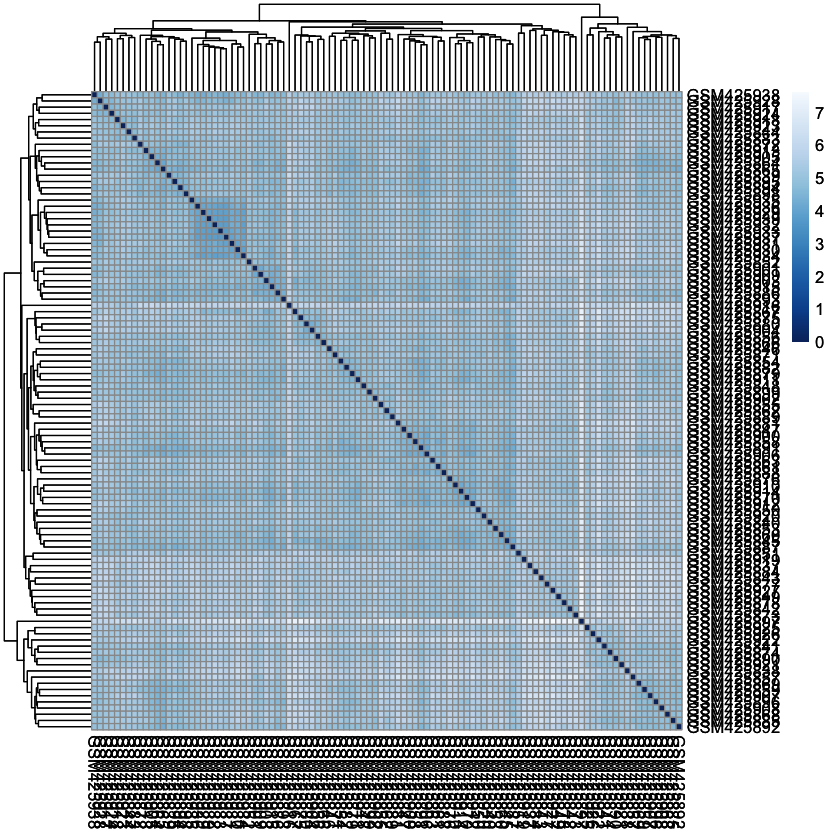

In [180]:

library(gplots)
library(pheatmap)

png("qc-heatmap-samples.png", w=1000, h=1000, pointsize=20)
# heatmap.2(sampleDistsMatrix, key=F, trace="none",
#         col=colorpanel(100, "black", "white"),
#          ColSideColors=mycols[colData$condition], RowSideColors=mycols[colData$condition],
#          margin=c(10, 10), main="Sample Distance Matrix")
colors <- colorRampPalette(rev(brewer.pal(9,"Blues")))(255)


ht <- pheatmap(sampleDistsMatrix,
               clustering_distance_cols = sampleDists,
               clustering_distance_rows = sampleDists,
               color = colors
              )
ht

In [183]:
pdf("003_correlation_cross_samples_heatmap.pdf",width = 20, height = 20)
ht
dev.off()

pdf 
  2

14. MA plot
- log2 折叠变换和平均正常统计量的关系，红色的点表示在10%FDR的基因

In [184]:
### MA plot ------------------------------------------------------------------------------>
pdf("004_DESeq2_MA_plot.pdf",width = 8, height = 8)
par(mfrow=c(1,1))
DESeq2::plotMA(res, main="DESeq2", ylim=c(-20,20))
dev.off()

pdf 
  2

15. nbinomTest的p值统计直方图

In [185]:
pdf("005_nbinomTest_p_value.pdf",width = 8, height = 8)
hist(res$pvalue, breaks = 100, col = 'skyblue', border = 'slateblue', main = 'nbinomTest p value')
dev.off()

pdf 
  2

16. rld to PCA(vst is better than rlog when n>=30)

In [167]:
pdf("006_PCAplot.pdf", width = 8, height = 8)
plotPCA(rld,intgroup=c("condition"))
dev.off()

pdf 
  2

17. 这个heatmap干嘛的？

In [187]:
library(ggplot2)
d <- plotCounts(dds,gene=which.min(res$padj), intgroup = "condition",returnData = TRUE)

In [189]:
pdf("007_jitter_plot_for_min_pvalue_transcript_counts.pdf", height = 8, width = 8)
ggplot(d,aes(x=condition,y=count))+
  geom_point(position = position_jitter(w=0.1,h=0))+
  scale_y_log10(breaks=c(25,100,400))
dev.off()

pdf 
  2

18. 处理res数据并且输出DEG表格

In [210]:
### deal with res and extract DEG!!! ----------------------------------------------------->
# resOrdered <- res[order(res$padj),]
# resOrdered[which(resOrdered$log2FoldChange >= 1 & resOrdered$padj < 0.05),'sig'] <- 'up'
# resOrdered[which(resOrdered$log2FoldChange <= -1 & resOrdered$padj < 0.05),'sig'] <- 'down'
# resOrdered[which(abs(resOrdered$log2FoldChange) <= 1 | resOrdered$padj >= 0.05),'sig'] <- 'none'

resOrdered <- res[order(res$padj),]
resOrdered[which(resOrdered$log2FoldChange >= 0.3 & resOrdered$pvalue<0.001),'sig'] <- 'up'
resOrdered[which(resOrdered$log2FoldChange <= -0.3 & resOrdered$pvalue<0.001),'sig'] <- 'down'
resOrdered[which(abs(resOrdered$log2FoldChange) <= 0.3 & resOrdered$pvalue>=0.001),'sig'] <- 'none'
resOrdered=as.data.frame(resOrdered)
write.table(resOrdered,"deseq2.all_sample.results.csv",col.names = NA, sep = "\t", quote = FALSE)

deg <- subset(resOrdered, (abs(resOrdered$log2FoldChange) >=0.3 & resOrdered$pvalue<0.001)) ##### extract DEG !
deg_matrix <- as.data.frame(deg)
write.table(deg_matrix, 'deg_result.csv', col.names = NA, sep = "\t", quote = FALSE)

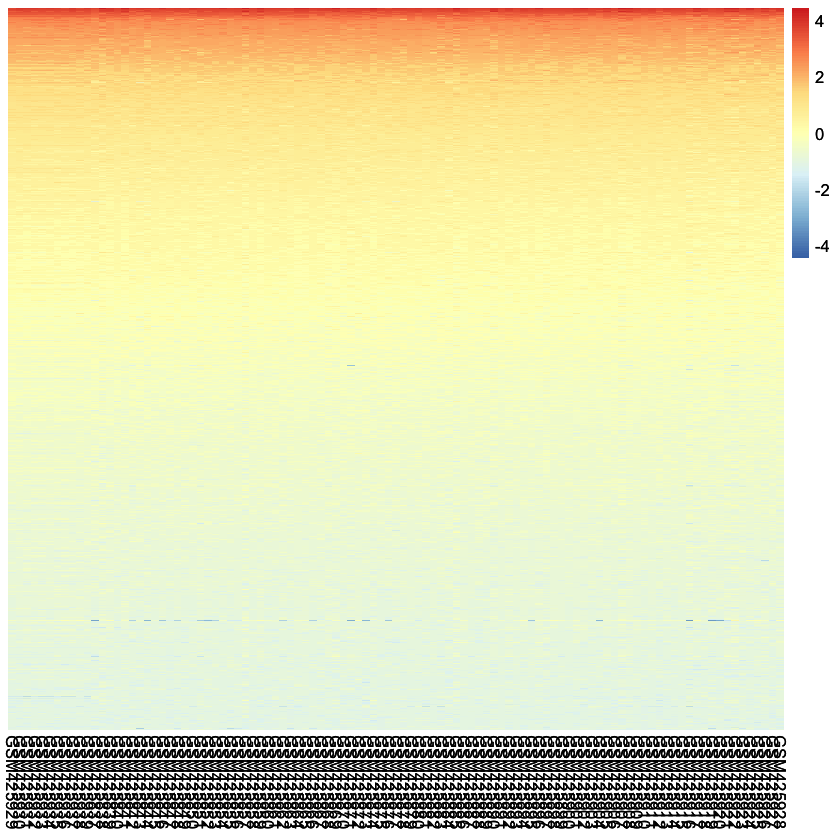

In [224]:
### plot heatmap ------------------------------------------------------------------------->
### plot all genes heatmap
select <- order(rowMeans(counts(dds,normalized=TRUE)),
                decreasing=TRUE)[1:1000]  ### select first ordered 1000 genes(not deg)
#                 decreasing=TRUE)[1:50]  ### select first ordered 66 genes(not deg)
df <- as.data.frame(colData(dds)[,c("condition")])
p1000 <- pheatmap(assay(rld)[select,], cluster_rows=FALSE, show_rownames=FALSE,
         cluster_cols=FALSE,scale = "column")
p1000

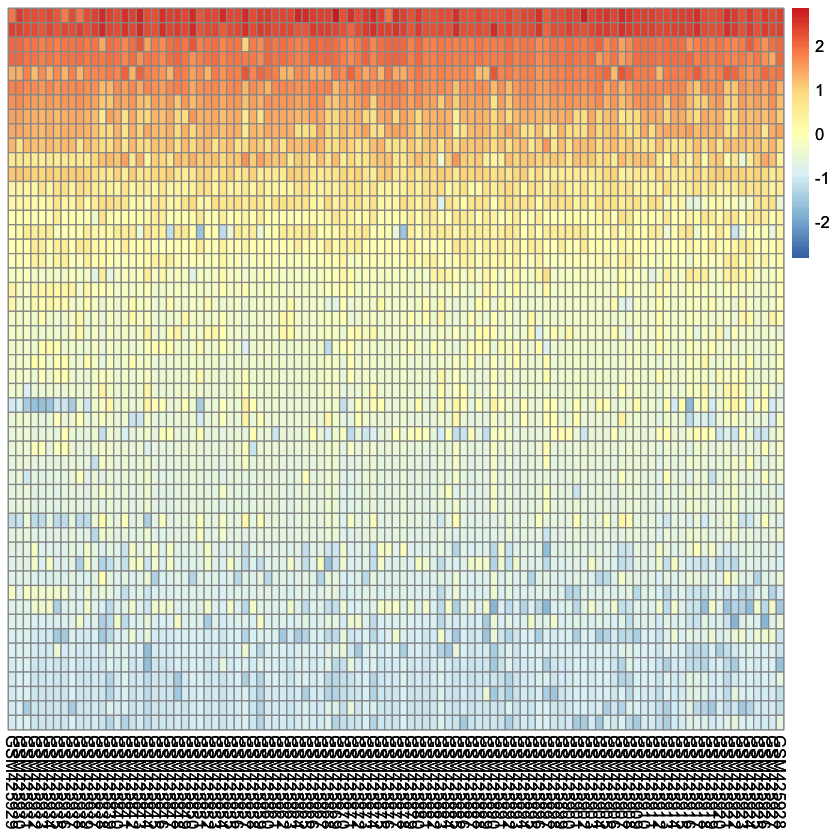

In [225]:
select <- order(rowMeans(counts(dds,normalized=TRUE)),
#                 decreasing=TRUE)[1:1000]  ### select first ordered 1000 genes(not deg)
                decreasing=TRUE)[1:50]  ### select first ordered 66 genes(not deg)
df <- as.data.frame(colData(dds)[,c("condition")])
p50 <- pheatmap(assay(rld)[select,], cluster_rows=FALSE, show_rownames=FALSE,
         cluster_cols=FALSE,scale = "column")
p50

In [227]:
pdf("008_select_first_ordered_1000_transcriptsOrGenes_plot_heatmap.pdf",height = 20,width = 20)
p1000
dev.off()
pdf("009_select_first_ordered_50_transcriptsOrGenes_plot_heatmap.pdf",height = 20,width = 20)
p50
dev.off()

pdf 
  2

pdf 
  2

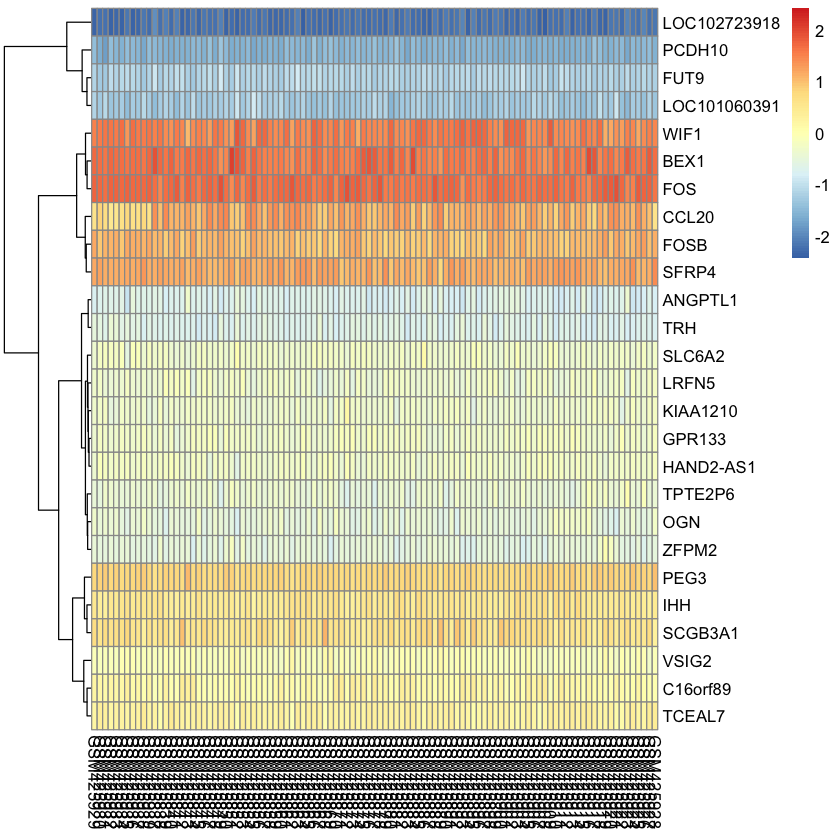

In [234]:
### plot DEG heatmap
selected <- rownames(deg)
pDEG <- pheatmap(assay(rld)[rownames(rld) %in% selected,], cluster_rows=TRUE, show_rownames=TRUE,
         cluster_cols=FALSE, scale = "column")

In [236]:
pdf("010_select_differential_expression_genes_heatmap.pdf",height = 5,width = 20)
pDEG
dev.off()

pdf 
  2

Warning message:
“Removed 1446 rows containing missing values (geom_point).”


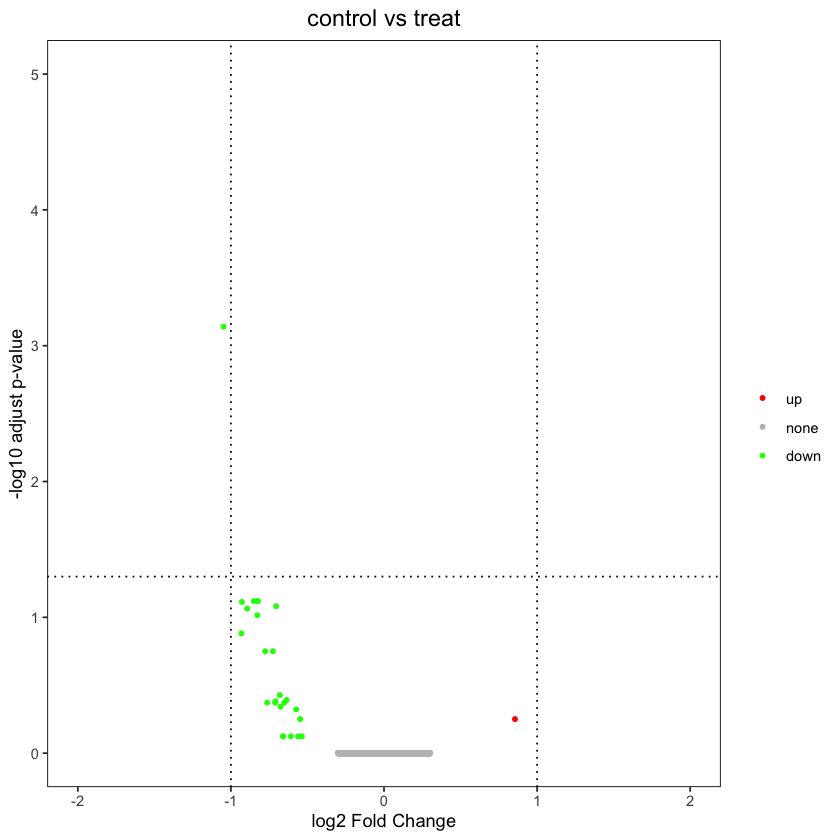

In [245]:
### plot valcano ------------------------------------------------------------------------>
vp <- ggplot(data = resOrdered, aes(x = log2FoldChange, y = -log10(padj),color = sig)) +
  geom_point(size = 1) +  #绘制散点图
  scale_color_manual(values = c('red', 'gray', 'green'), limits = c('up', 'none', 'down')) +  #自定义点的颜色
  labs(x = 'log2 Fold Change', y = '-log10 adjust p-value', title = 'control vs treat', color = '') +  #坐标轴标题
  theme(plot.title = element_text(hjust = 0.5, size = 14), panel.grid = element_blank(), #背景色、网格线、图例等主题修改
        panel.background = element_rect(color = 'black', fill = 'transparent'),
        legend.key = element_rect(fill = 'transparent')) +
  geom_vline(xintercept = c(-1, 1), lty = 3, color = 'black') +  #添加阈值线
  geom_hline(yintercept = 1.3, lty = 3, color = 'black') +
  xlim(-2, 2) + ylim(0, 5)
vp

In [246]:
pdf("011_select_differential_expression_genes_valcano_plot.pdf",height = 5,width = 5)
vp
dev.off()

Warning message:
“Removed 1446 rows containing missing values (geom_point).”


pdf 
  2